<a href="https://colab.research.google.com/github/solareonk/exploratory-/blob/main/Bank_Telemarketing_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏦 Bank Telemarketing - Data Mining Project
## Modul 2: Python for Data Analysis

**Mata Kuliah:** Machine Learning  
**Dataset:** Bank Marketing Dataset (Portuguese Banking Institution)  
**Tujuan:** Melakukan percobaan dari pemahaman data hingga Exploratory Data Analysis (EDA)

---

## 1. Import Library

Mengimpor seluruh library yang dibutuhkan untuk analisis data.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi visualisasi
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_palette('Set2')

print("✅ Semua library berhasil diimport!")

✅ Semua library berhasil diimport!


## 2. Load Dataset

Dataset yang digunakan adalah data telemarketing dari bank di Portugal (Kaggle).  
Promosi dilakukan lewat telepon untuk menawarkan nasabah membuka deposito.

- Label **'yes'** → nasabah mau membuka deposito  
- Label **'no'** → nasabah tidak mau membuka deposito

In [ ]:
# Upload dataset langsung dari komputer
# Jalankan cell ini → klik "Choose Files" → pilih file CSV-nya
from google.colab import files

print("⬆️  Klik tombol 'Choose Files' di bawah ini, lalu pilih file bank-telemarketing.csv")
print()
uploaded = files.upload()

# Otomatis baca file yang diupload
import io
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]), sep=';')

print()
print(f"✅ Dataset '{filename}' berhasil dimuat!")
print(f"Jumlah baris  : {df.shape[0]:,}")
print(f"Jumlah kolom  : {df.shape[1]}")

## 3. Pemahaman Data (About Data)

### 3.1 Struktur Data
Data terdiri dari 3 kategori:
1. **Data Profil Nasabah** — `age`, `job`, `marital`, `education`, `default`, `housing`, `loan`
2. **Data Kontak Terakhir** — `contact`, `month`, `day_of_week`, `duration`, `campaign`, `pdays`, `previous`, `poutcome`
3. **Data Ekonomi & Label** — `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`, `y`

In [5]:
# Menampilkan 5 data pertama
print("=" * 80)
print("PREVIEW DATA (5 BARIS PERTAMA)")
print("=" * 80)
df.head()

PREVIEW DATA (5 BARIS PERTAMA)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,98.0,retired,married,basic.4y,unknown,yes,no,cellular,oct,fri,...,1,2,2,success,-3.4,92.431,-26.9,0.730,5017.5,yes
1,98.0,retired,married,basic.4y,unknown,yes,no,cellular,oct,fri,...,2,999,0,nonexistent,-3.4,92.431,-26.9,0.730,5017.5,yes
2,95.0,retired,divorced,basic.6y,no,no,no,cellular,mar,thu,...,1,999,0,nonexistent,-1.8,92.843,-50.0,1.650,5099.1,no
3,94.0,retired,married,basic.9y,no,no,no,cellular,nov,wed,...,1,999,1,failure,-3.4,92.649,-30.1,0.716,5017.5,no
4,92.0,retired,married,unknown,no,yes,no,cellular,may,thu,...,1,6,2,success,-1.8,93.876,-40.0,0.683,5008.7,no


In [6]:
# Menampilkan 5 data terakhir
print("=" * 80)
print("PREVIEW DATA (5 BARIS TERAKHIR)")
print("=" * 80)
df.tail()

PREVIEW DATA (5 BARIS TERAKHIR)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41210,32.0,technician,single,university.degree,no,yes,no,cellular,aug,tue,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,no
41211,32.0,technician,married,university.degree,no,no,yes,cellular,aug,tue,...,2,999,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,no
41212,32.0,technician,married,university.degree,no,yes,no,cellular,aug,tue,...,2,999,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,no
41213,32.0,admin.,divorced,university.degree,no,no,no,cellular,aug,tue,...,2,999,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,no
41214,32.0,technician,single,university.degree,no,yes,no,cellular,aug,tue,...,2,999,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,no


In [7]:
# Info dataset
print("=" * 80)
print("INFORMASI DATASET")
print("=" * 80)
df.info()

INFORMASI DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41215 entries, 0 to 41214
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41200 non-null  float64
 1   job             41215 non-null  object 
 2   marital         41215 non-null  object 
 3   education       41215 non-null  object 
 4   default         41215 non-null  object 
 5   housing         41215 non-null  object 
 6   loan            41215 non-null  object 
 7   contact         41215 non-null  object 
 8   month           41215 non-null  object 
 9   day_of_week     41215 non-null  object 
 10  duration        41215 non-null  int64  
 11  campaign        41215 non-null  int64  
 12  pdays           41215 non-null  int64  
 13  previous        41215 non-null  int64  
 14  poutcome        41215 non-null  object 
 15  emp.var.rate    41215 non-null  float64
 16  cons.price.idx  41215 non-null  float64
 17  cons.conf.idx

In [8]:
# Tipe data
print("=" * 80)
print("TIPE DATA PER KOLOM")
print("=" * 80)
print()
numerik = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
kategorikal = df.select_dtypes(include=['object']).columns.tolist()

print(f"Fitur Numerik   ({len(numerik)} kolom)  : {numerik}")
print(f"Fitur Kategorikal ({len(kategorikal)} kolom): {kategorikal}")

TIPE DATA PER KOLOM

Fitur Numerik   (10 kolom)  : ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Fitur Kategorikal (11 kolom): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


In [9]:
# Jumlah data unik per kolom
print("=" * 80)
print("JUMLAH DATA UNIK PER KOLOM")
print("=" * 80)
print()
for col in df.columns:
    print(f"{col:20s} : {df[col].nunique()} nilai unik")

JUMLAH DATA UNIK PER KOLOM

age                  : 78 nilai unik
job                  : 12 nilai unik
marital              : 4 nilai unik
education            : 8 nilai unik
default              : 3 nilai unik
housing              : 3 nilai unik
loan                 : 3 nilai unik
contact              : 2 nilai unik
month                : 10 nilai unik
day_of_week          : 5 nilai unik
duration             : 1544 nilai unik
campaign             : 42 nilai unik
pdays                : 27 nilai unik
previous             : 8 nilai unik
poutcome             : 3 nilai unik
emp.var.rate         : 10 nilai unik
cons.price.idx       : 26 nilai unik
cons.conf.idx        : 26 nilai unik
euribor3m            : 316 nilai unik
nr.employed          : 11 nilai unik
y                    : 2 nilai unik


### 3.2 Statistika Deskriptif

In [10]:
# Statistika deskriptif untuk data numerik
print("=" * 80)
print("STATISTIKA DESKRIPTIF - DATA NUMERIK")
print("=" * 80)
df.describe().round(2)

STATISTIKA DESKRIPTIF - DATA NUMERIK


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41200.00,41215.00,41215.00,41215.00,41215.00,41215.00,41215.00,41215.00,41215.00,41215.00
mean,40.03,258.31,2.57,962.43,0.17,0.08,93.58,-40.50,3.62,5167.03
std,10.43,259.26,2.77,187.03,0.49,1.57,0.58,4.63,1.73,72.27
min,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.00,102.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,180.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,319.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.00,4918.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10


In [11]:
# Statistika deskriptif untuk data kategorikal
print("=" * 80)
print("STATISTIKA DESKRIPTIF - DATA KATEGORIKAL")
print("=" * 80)
df.describe(include='object')

STATISTIKA DESKRIPTIF - DATA KATEGORIKAL


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41215,41215,41215,41215,41215,41215,41215,41215,41215,41215,41215
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10431,24947,12186,32613,21589,33971,26169,13769,8629,35586,36568


**Catatan dari Statistika Deskriptif:**
- Kolom `age`, `campaign`, `nr.employed`, `euribor3m`, `cons.conf.idx`, `emp.var.rate`, `cons.price.idx` memiliki nilai min dan max yang masuk akal.
- `duration` memiliki nilai max jauh di atas Q3 → kolom ini nanti akan di-drop.
- `pdays` memiliki Q1, Q2, Q3 bernilai 999 → perlu di-clean lebih lanjut.
- Kolom `previous` memiliki Q1, Q2, Q3 bernilai 0 → perlu dilihat lebih lanjut.

## 4. Business Problem

| Kondisi Saat Ini | Goals I | Goals II |
|:---:|:---:|:---:|
| **Success Rate 11.1%** | **Success Rate > 40%** | **Segmentasi Nasabah** |
| Dari total nasabah yang ditelpon, hanya ~11% yang menaruh deposito | Meningkatkan success rate telemarketing | Promosi terarah sesuai profil nasabah |

In [12]:
# Menghitung success rate saat ini
total_nasabah = len(df)
nasabah_yes = len(df[df['y'] == 'yes'])
nasabah_no = len(df[df['y'] == 'no'])
success_rate = nasabah_yes / total_nasabah * 100

print("=" * 80)
print("BUSINESS PROBLEM - KONDISI SAAT INI")
print("=" * 80)
print()
print(f"Total nasabah yang ditelpon : {total_nasabah:,}")
print(f"Nasabah yang deposito (yes) : {nasabah_yes:,}")
print(f"Nasabah yang menolak (no)   : {nasabah_no:,}")
print(f"Success Rate                : {success_rate:.1f}%")
print()
print(f">>> Dari {total_nasabah:,} nasabah yang ditelpon,")
print(f"    hanya {nasabah_yes:,} ({success_rate:.1f}%) yang mau menaruh deposito.")

BUSINESS PROBLEM - KONDISI SAAT INI

Total nasabah yang ditelpon : 41,215
Nasabah yang deposito (yes) : 4,647
Nasabah yang menolak (no)   : 36,568
Success Rate                : 11.3%

>>> Dari 41,215 nasabah yang ditelpon,
    hanya 4,647 (11.3%) yang mau menaruh deposito.


## 5. Data Cleaning

### 5.1 Cek Kondisi Data

In [13]:
# Cek kondisi data secara keseluruhan
print("=" * 80)
print("KONDISI DATA")
print("=" * 80)
print()
print(f"Banyak baris         : {df.shape[0]:,}")
print(f"Total fitur/kolom    : {df.shape[1]}")
print()

# Cek missing values (NaN)
print("--- Missing Values (NaN) ---")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("Tidak ada NaN secara eksplisit.")
else:
    print(missing[missing > 0])

print()

# Cek nilai 'unknown' per kolom kategorikal
print("--- Nilai 'unknown' per Kolom Kategorikal ---")
for col in df.select_dtypes(include='object').columns:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        pct = unknown_count / len(df) * 100
        print(f"  {col:15s} : {unknown_count:,} records ({pct:.1f}%)")

print()

# Cek duplikasi
dup_count = df.duplicated().sum()
print(f"--- Duplicate Data ---")
print(f"Jumlah data duplikat : {dup_count} records")

KONDISI DATA

Banyak baris         : 41,215
Total fitur/kolom    : 21

--- Missing Values (NaN) ---
age    15
dtype: int64

--- Nilai 'unknown' per Kolom Kategorikal ---
  job             : 330 records (0.8%)
  marital         : 80 records (0.2%)
  education       : 1,731 records (4.2%)
  default         : 8,599 records (20.9%)
  housing         : 991 records (2.4%)
  loan            : 991 records (2.4%)

--- Duplicate Data ---
Jumlah data duplikat : 39 records


### 5.2 Hapus Data Duplikat

In [14]:
# Drop duplikat, simpan data terakhir
print(f"Jumlah data SEBELUM drop duplikat : {len(df):,}")
df = df.drop_duplicates(keep='last')
print(f"Jumlah data SETELAH drop duplikat : {len(df):,}")
print(f"Data duplikat yang dihapus        : {dup_count}")

Jumlah data SEBELUM drop duplikat : 41,215
Jumlah data SETELAH drop duplikat : 41,176
Data duplikat yang dihapus        : 39


### 5.3 Handling Missing Values

#### 5.3.1 Kolom `age` — Imputasi dengan rata-rata umur per pekerjaan

Jika terdapat nilai age yang hilang/kosong, diisi dengan rata-rata umur berdasarkan bidang pekerjaan.

In [15]:
# Cek apakah ada age yang kosong atau anomali
print("--- Cek kolom 'age' ---")
print(f"Jumlah NaN pada age    : {df['age'].isnull().sum()}")
print(f"Nilai minimum age      : {df['age'].min()}")
print(f"Nilai maksimum age     : {df['age'].max()}")
print()

# Jika ada NaN, lakukan imputasi berdasarkan rata-rata umur per job
if df['age'].isnull().sum() > 0:
    print("Melakukan imputasi age berdasarkan rata-rata per job...")
    print()
    # Rata-rata umur per job
    age_mean_per_job = df.groupby('job')['age'].mean().round(2)
    print("Rata-rata umur per job:")
    print(age_mean_per_job)
    print()

    # Imputasi
    for job in df.loc[df['age'].isnull(), 'job'].unique():
        mean_age = age_mean_per_job[job]
        df.loc[(df['age'].isnull()) & (df['job'] == job), 'age'] = round(mean_age)

    print(f"Setelah imputasi, NaN pada age: {df['age'].isnull().sum()}")
else:
    print("Tidak ada missing values pada kolom 'age'. ✅")

--- Cek kolom 'age' ---
Jumlah NaN pada age    : 15
Nilai minimum age      : 17.0
Nilai maksimum age     : 98.0

Melakukan imputasi age berdasarkan rata-rata per job...

Rata-rata umur per job:
job
admin.           38.19
blue-collar      39.55
entrepreneur     41.72
housemaid        45.50
management       42.36
retired          62.04
self-employed    39.95
services         37.93
student          25.89
technician       38.51
unemployed       39.73
unknown          45.56
Name: age, dtype: float64

Setelah imputasi, NaN pada age: 0


#### 5.3.2 Kolom `marital` — Hapus data 'unknown'

Persentase unknown < 5%, maka data 'unknown' dibuang.

In [16]:
# Handling marital 'unknown'
unknown_marital = (df['marital'] == 'unknown').sum()
pct_marital = unknown_marital / len(df) * 100
print(f"Jumlah marital 'unknown' : {unknown_marital} ({pct_marital:.2f}%)")
print(f"Karena < 5%, data dibuang.")
print()

df = df[df['marital'] != 'unknown']
print(f"Jumlah data setelah drop marital unknown : {len(df):,}")

Jumlah marital 'unknown' : 80 (0.19%)
Karena < 5%, data dibuang.

Jumlah data setelah drop marital unknown : 41,096


#### 5.3.3 Kolom `default` — Drop kolom

- 20% bernilai 'unknown' → tidak bisa dibuang record-nya
- Hanya 3 data bernilai 'yes' (<1%) → fitur tidak relevan
- **Keputusan: Drop seluruh kolom `default`**

In [17]:
# Cek distribusi default
print("Distribusi kolom 'default':")
print(df['default'].value_counts())
print()

# Drop kolom default
df = df.drop(columns=['default'])
print("Kolom 'default' berhasil di-drop. ✅")
print(f"Jumlah kolom sekarang: {df.shape[1]}")

Distribusi kolom 'default':
default
no         32508
unknown     8585
yes            3
Name: count, dtype: int64

Kolom 'default' berhasil di-drop. ✅
Jumlah kolom sekarang: 20


#### 5.3.4 Kolom `housing` — Hapus data 'unknown'

In [18]:
# Handling housing 'unknown'
unknown_housing = (df['housing'] == 'unknown').sum()
pct_housing = unknown_housing / len(df) * 100
print(f"Jumlah housing 'unknown' : {unknown_housing} ({pct_housing:.2f}%)")

df = df[df['housing'] != 'unknown']
print(f"Jumlah data setelah drop housing unknown : {len(df):,}")

Jumlah housing 'unknown' : 989 (2.41%)
Jumlah data setelah drop housing unknown : 40,107


#### 5.3.5 Kolom `education` — Hapus data 'unknown'

In [19]:
# Handling education 'unknown'
unknown_edu = (df['education'] == 'unknown').sum()
pct_edu = unknown_edu / len(df) * 100
print(f"Jumlah education 'unknown' : {unknown_edu} ({pct_edu:.2f}%)")

df = df[df['education'] != 'unknown']
print(f"Jumlah data setelah drop education unknown : {len(df):,}")

Jumlah education 'unknown' : 1681 (4.19%)
Jumlah data setelah drop education unknown : 38,426


### 5.4 Handling Unwanted Values

#### 5.4.1 Kolom `pdays` → Transformasi menjadi `ever_call`

- Nilai 999 artinya nasabah belum pernah dihubungi sebelumnya.
- Kolom diubah menjadi binary: `ever_call` = 'yes' / 'no'

In [20]:
# Cek distribusi pdays
print("Distribusi pdays (top 10 nilai):")
print(df['pdays'].value_counts().head(10))
print()

pdays_999 = (df['pdays'] == 999).sum()
print(f"Jumlah pdays = 999 : {pdays_999:,} ({pdays_999/len(df)*100:.1f}%)")
print()

# Transformasi pdays → ever_call
df['ever_call'] = df['pdays'].apply(lambda x: 'no' if x == 999 else 'yes')

print("Distribusi ever_call:")
print(df['ever_call'].value_counts())
print()

# Drop kolom pdays
df = df.drop(columns=['pdays'])
print("Kolom 'pdays' di-drop dan diganti 'ever_call'. ✅")

Distribusi pdays (top 10 nilai):
pdays
999    37047
3        400
6        381
4        106
2         59
9         55
12        53
7         52
5         45
10        44
Name: count, dtype: int64

Jumlah pdays = 999 : 37,047 (96.4%)

Distribusi ever_call:
ever_call
no     37047
yes     1379
Name: count, dtype: int64

Kolom 'pdays' di-drop dan diganti 'ever_call'. ✅


#### 5.4.2 Kolom `poutcome` — Ubah 'nonexistent' menjadi 'failure'

In [21]:
# Cek distribusi poutcome
print("Distribusi poutcome SEBELUM:")
print(df['poutcome'].value_counts())
print()

# Ubah nonexistent → failure
df['poutcome'] = df['poutcome'].replace('nonexistent', 'failure')

print("Distribusi poutcome SETELAH:")
print(df['poutcome'].value_counts())
print("✅ 'nonexistent' berhasil diubah menjadi 'failure'")

Distribusi poutcome SEBELUM:
poutcome
nonexistent    33224
failure         3946
success         1256
Name: count, dtype: int64

Distribusi poutcome SETELAH:
poutcome
failure    37170
success     1256
Name: count, dtype: int64
✅ 'nonexistent' berhasil diubah menjadi 'failure'


### 5.5 Ringkasan Hasil Data Cleaning

In [22]:
print("=" * 80)
print("RINGKASAN HASIL DATA CLEANING")
print("=" * 80)
print()
print(f"Jumlah baris  : {df.shape[0]:,}")
print(f"Jumlah kolom  : {df.shape[1]}")
print()
print("Kolom yang tersisa:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")
print()
print("Cek missing values setelah cleaning:")
print(df.isnull().sum().sum(), "missing values")
print()
print("Cek unknown values setelah cleaning:")
for col in df.select_dtypes(include='object').columns:
    unk = (df[col] == 'unknown').sum()
    if unk > 0:
        print(f"  {col}: {unk}")
if all((df[col] == 'unknown').sum() == 0 for col in df.select_dtypes(include='object').columns):
    print("  Tidak ada lagi nilai 'unknown'. ✅")

RINGKASAN HASIL DATA CLEANING

Jumlah baris  : 38,426
Jumlah kolom  : 20

Kolom yang tersisa:
   1. age
   2. job
   3. marital
   4. education
   5. housing
   6. loan
   7. contact
   8. month
   9. day_of_week
  10. duration
  11. campaign
  12. previous
  13. poutcome
  14. emp.var.rate
  15. cons.price.idx
  16. cons.conf.idx
  17. euribor3m
  18. nr.employed
  19. y
  20. ever_call

Cek missing values setelah cleaning:
0 missing values

Cek unknown values setelah cleaning:
  job: 192


## 6. Exploratory Data Analysis (EDA)

### 6.1 Label Distribution

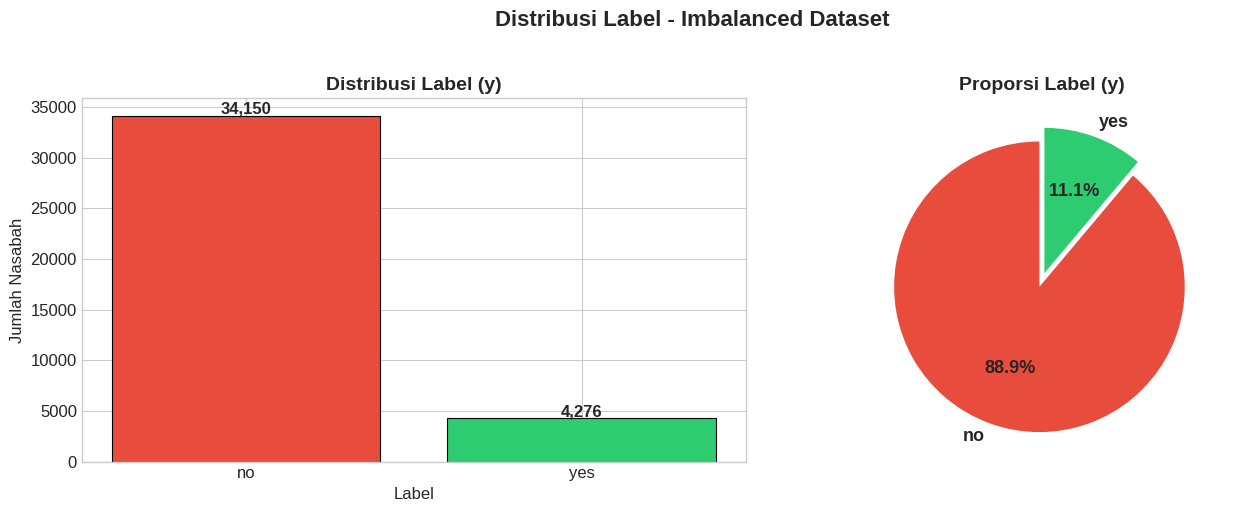


Data ini merupakan IMBALANCED DATASET
Proporsi 'yes': 11.1%  |  Proporsi 'no': 88.9%


In [23]:
# Label Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Countplot
label_counts = df['y'].value_counts()
colors = ['#e74c3c', '#2ecc71']
axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Distribusi Label (y)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Jumlah Nasabah')
for i, (idx, val) in enumerate(zip(label_counts.index, label_counts.values)):
    axes[0].text(i, val + 200, f'{val:,}', ha='center', fontweight='bold', fontsize=12)

# Pie chart
axes[1].pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0.05, 0.05),
            textprops={'fontsize': 13, 'fontweight': 'bold'})
axes[1].set_title('Proporsi Label (y)', fontsize=14, fontweight='bold')

plt.suptitle('Distribusi Label - Imbalanced Dataset', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

pct_yes = label_counts['yes'] / len(df) * 100
print(f"\nData ini merupakan IMBALANCED DATASET")
print(f"Proporsi 'yes': {pct_yes:.1f}%  |  Proporsi 'no': {100-pct_yes:.1f}%")

### 6.2 Distribusi Umur (Age)

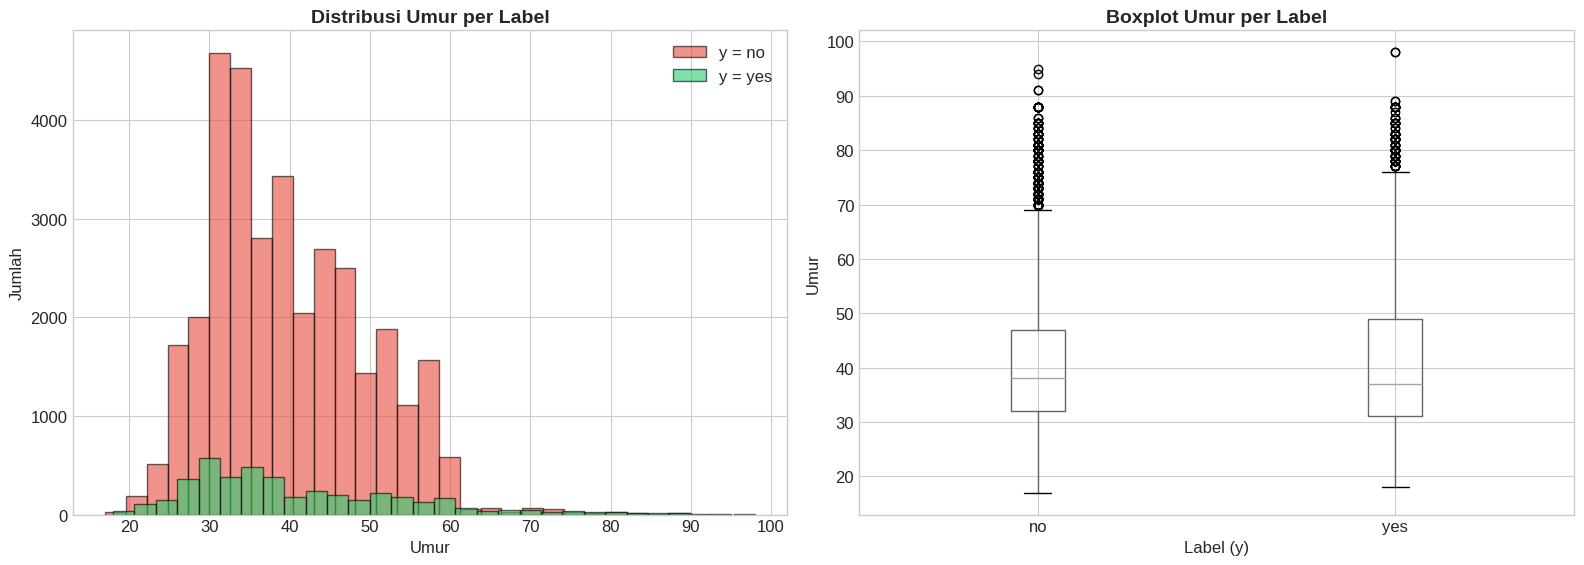

Insight:
- Nasabah usia 30-55 tahun cenderung MENOLAK deposito
- Nasabah usia 60+ tahun cenderung MENERIMA deposito


In [24]:
# Age distribution per label
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
for label, color in zip(['no', 'yes'], ['#e74c3c', '#2ecc71']):
    subset = df[df['y'] == label]
    axes[0].hist(subset['age'], bins=30, alpha=0.6, label=f'y = {label}', color=color, edgecolor='black')
axes[0].set_title('Distribusi Umur per Label', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Umur')
axes[0].set_ylabel('Jumlah')
axes[0].legend()

# Boxplot
df.boxplot(column='age', by='y', ax=axes[1])
axes[1].set_title('Boxplot Umur per Label', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Label (y)')
axes[1].set_ylabel('Umur')
plt.suptitle('')

plt.tight_layout()
plt.show()

print("Insight:")
print("- Nasabah usia 30-55 tahun cenderung MENOLAK deposito")
print("- Nasabah usia 60+ tahun cenderung MENERIMA deposito")

### 6.3 Distribusi Pekerjaan (Job)

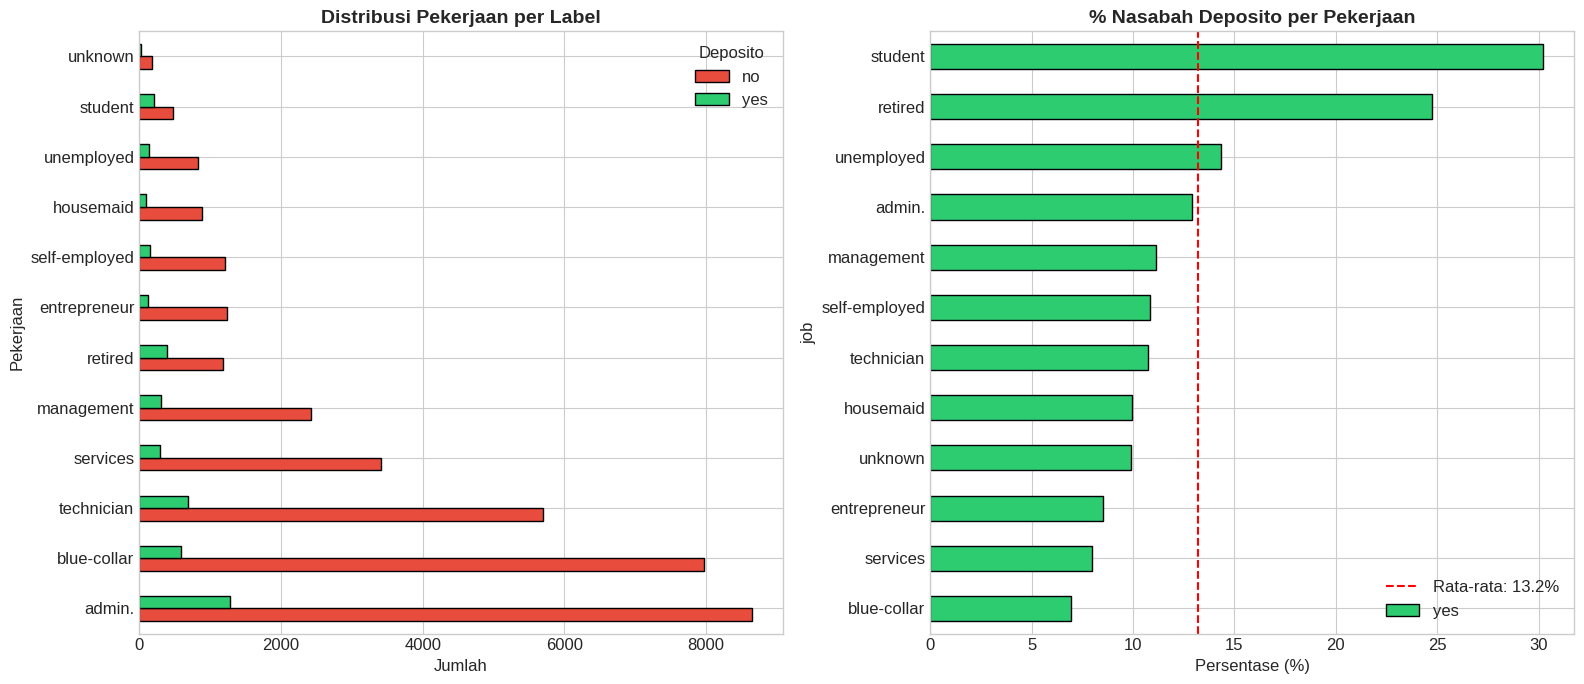

In [25]:
# Job distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Countplot per label
job_order = df['job'].value_counts().index
ct = pd.crosstab(df['job'], df['y'])
ct = ct.reindex(job_order)
ct.plot(kind='barh', stacked=False, ax=axes[0], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Distribusi Pekerjaan per Label', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Jumlah')
axes[0].set_ylabel('Pekerjaan')
axes[0].legend(title='Deposito')

# Persentase yes per job
pct = ct.div(ct.sum(axis=1), axis=0) * 100
pct['yes'].sort_values().plot(kind='barh', ax=axes[1], color='#2ecc71', edgecolor='black')
axes[1].set_title('% Nasabah Deposito per Pekerjaan', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Persentase (%)')
axes[1].axvline(x=pct['yes'].mean(), color='red', linestyle='--', label=f"Rata-rata: {pct['yes'].mean():.1f}%")
axes[1].legend()

plt.tight_layout()
plt.show()

### 6.4 Distribusi Pendidikan (Education)

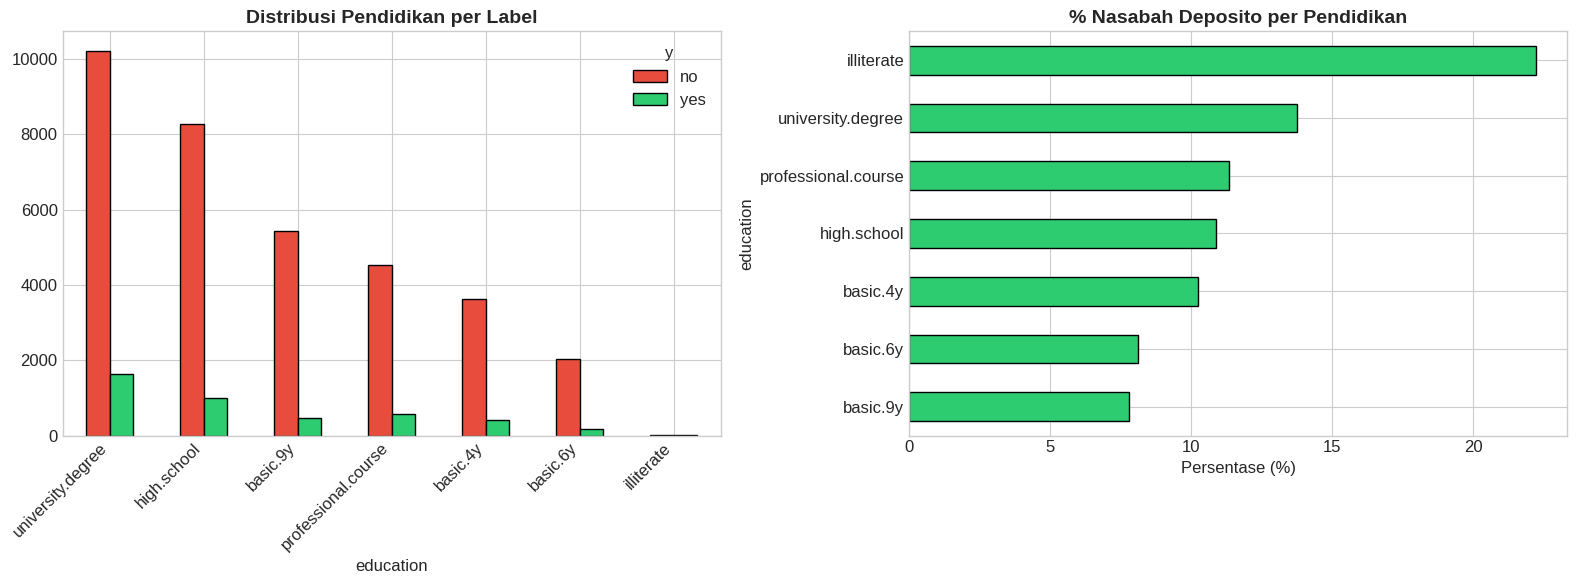

In [26]:
# Education distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

edu_order = df['education'].value_counts().index
ct_edu = pd.crosstab(df['education'], df['y']).reindex(edu_order)

ct_edu.plot(kind='bar', stacked=False, ax=axes[0], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Distribusi Pendidikan per Label', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

pct_edu = ct_edu.div(ct_edu.sum(axis=1), axis=0) * 100
pct_edu['yes'].sort_values().plot(kind='barh', ax=axes[1], color='#2ecc71', edgecolor='black')
axes[1].set_title('% Nasabah Deposito per Pendidikan', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Persentase (%)')

plt.tight_layout()
plt.show()

### 6.5 Distribusi Status Pernikahan (Marital)

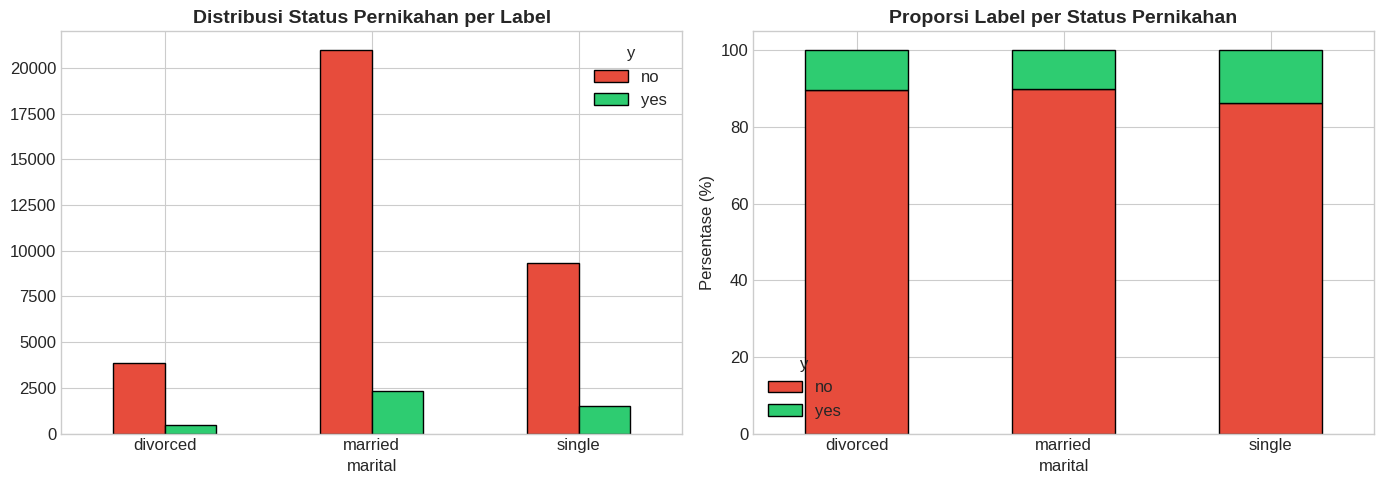

Insight: Distribusi status menikah pada setiap label tidak jauh berbeda.


In [27]:
# Marital distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ct_mar = pd.crosstab(df['marital'], df['y'])
ct_mar.plot(kind='bar', stacked=False, ax=axes[0], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Distribusi Status Pernikahan per Label', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

pct_mar = ct_mar.div(ct_mar.sum(axis=1), axis=0) * 100
pct_mar.plot(kind='bar', stacked=True, ax=axes[1], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[1].set_title('Proporsi Label per Status Pernikahan', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].set_ylabel('Persentase (%)')

plt.tight_layout()
plt.show()

print("Insight: Distribusi status menikah pada setiap label tidak jauh berbeda.")

### 6.6 Distribusi Housing & Loan

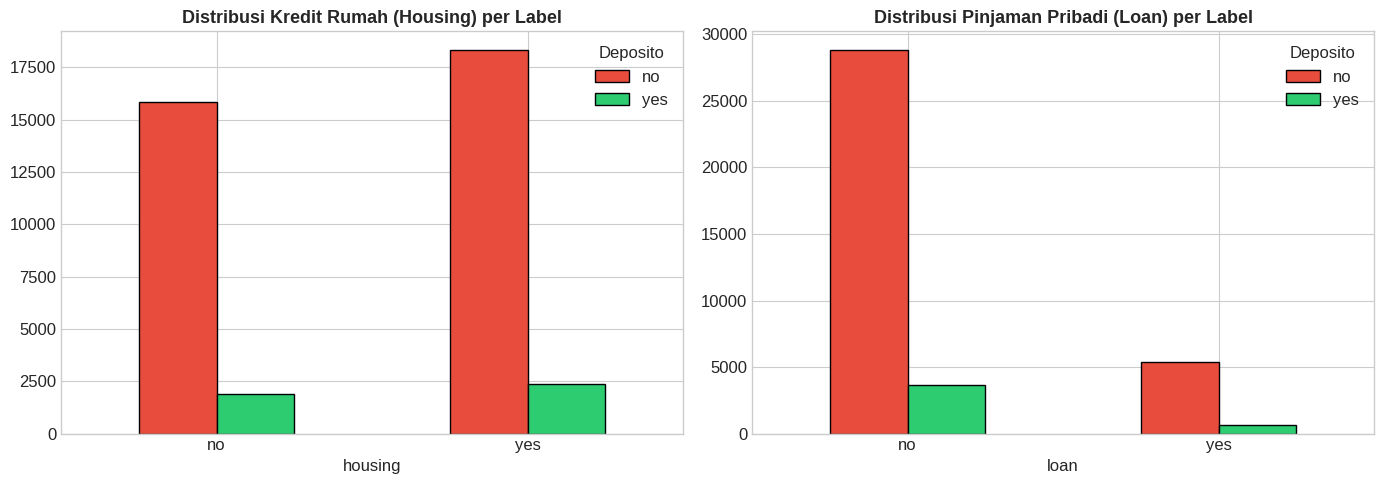

Insight: Distribusi housing dan loan tersebar cukup merata pada kedua label.


In [28]:
# Housing & Loan distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(axes, ['housing', 'loan'], ['Kredit Rumah (Housing)', 'Pinjaman Pribadi (Loan)']):
    ct = pd.crosstab(df[col], df['y'])
    ct.plot(kind='bar', stacked=False, ax=ax, color=['#e74c3c', '#2ecc71'], edgecolor='black')
    ax.set_title(f'Distribusi {title} per Label', fontsize=13, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title='Deposito')

plt.tight_layout()
plt.show()

print("Insight: Distribusi housing dan loan tersebar cukup merata pada kedua label.")

### 6.7 Distribusi Tipe Kontak & Hari

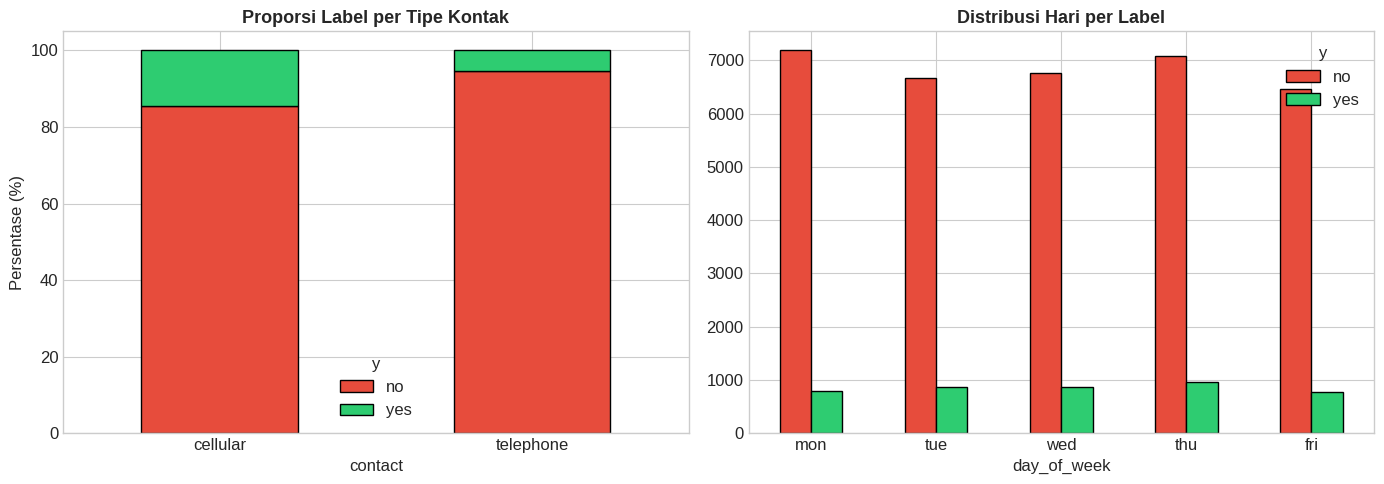

Insight:
- 83% nasabah yang deposito dikontak melalui cellular
- Persebaran hari cukup merata → hari bukan indikator kuat


In [29]:
# Contact & Day of week distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Contact
ct_contact = pd.crosstab(df['contact'], df['y'])
pct_contact = ct_contact.div(ct_contact.sum(axis=1), axis=0) * 100
pct_contact.plot(kind='bar', stacked=True, ax=axes[0], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Proporsi Label per Tipe Kontak', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].set_ylabel('Persentase (%)')

# Day of week
day_order = ['mon', 'tue', 'wed', 'thu', 'fri']
ct_day = pd.crosstab(df['day_of_week'], df['y']).reindex(day_order)
ct_day.plot(kind='bar', stacked=False, ax=axes[1], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[1].set_title('Distribusi Hari per Label', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

print("Insight:")
print("- 83% nasabah yang deposito dikontak melalui cellular")
print("- Persebaran hari cukup merata → hari bukan indikator kuat")

### 6.8 Distribusi Bulan Kontak (Month)

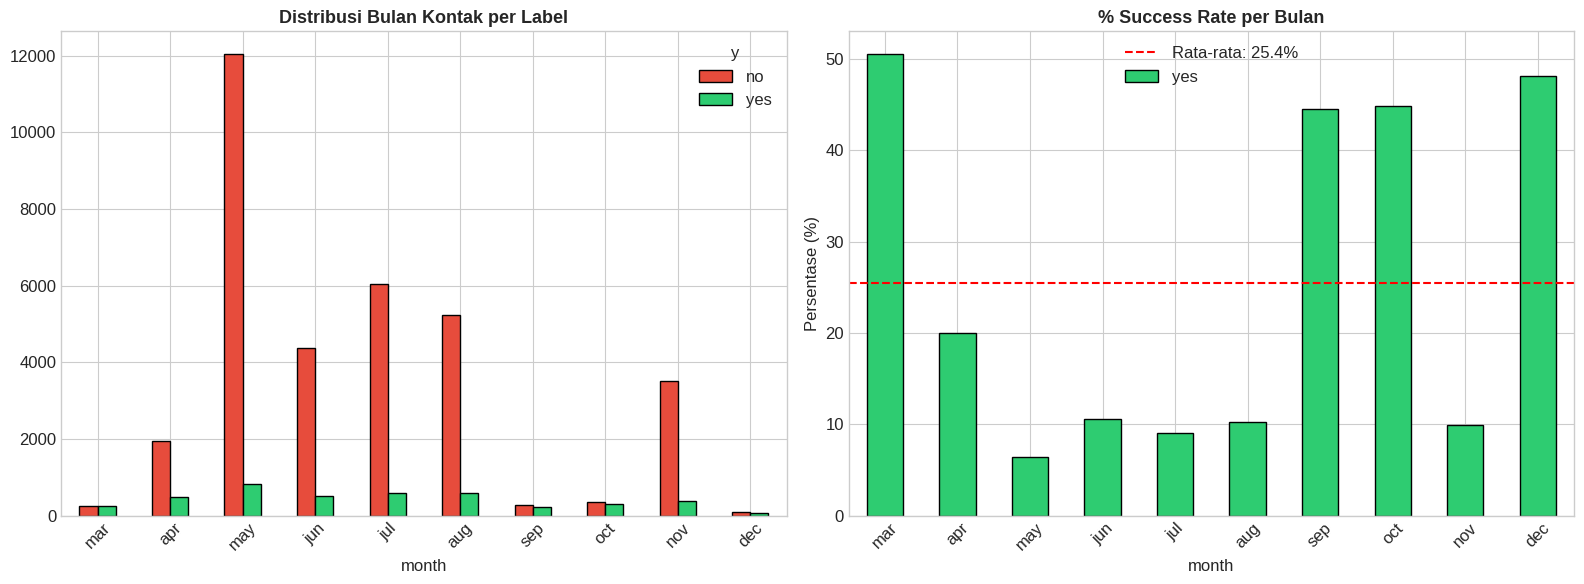

In [30]:
# Month distribution
month_order = ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
existing_months = [m for m in month_order if m in df['month'].unique()]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ct_month = pd.crosstab(df['month'], df['y']).reindex(existing_months)
ct_month.plot(kind='bar', stacked=False, ax=axes[0], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Distribusi Bulan Kontak per Label', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

pct_month = ct_month.div(ct_month.sum(axis=1), axis=0) * 100
pct_month['yes'].plot(kind='bar', ax=axes[1], color='#2ecc71', edgecolor='black')
axes[1].set_title('% Success Rate per Bulan', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Persentase (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)
axes[1].axhline(y=pct_month['yes'].mean(), color='red', linestyle='--', label=f"Rata-rata: {pct_month['yes'].mean():.1f}%")
axes[1].legend()

plt.tight_layout()
plt.show()

### 6.9 Distribusi Campaign, Previous, & Ever Call

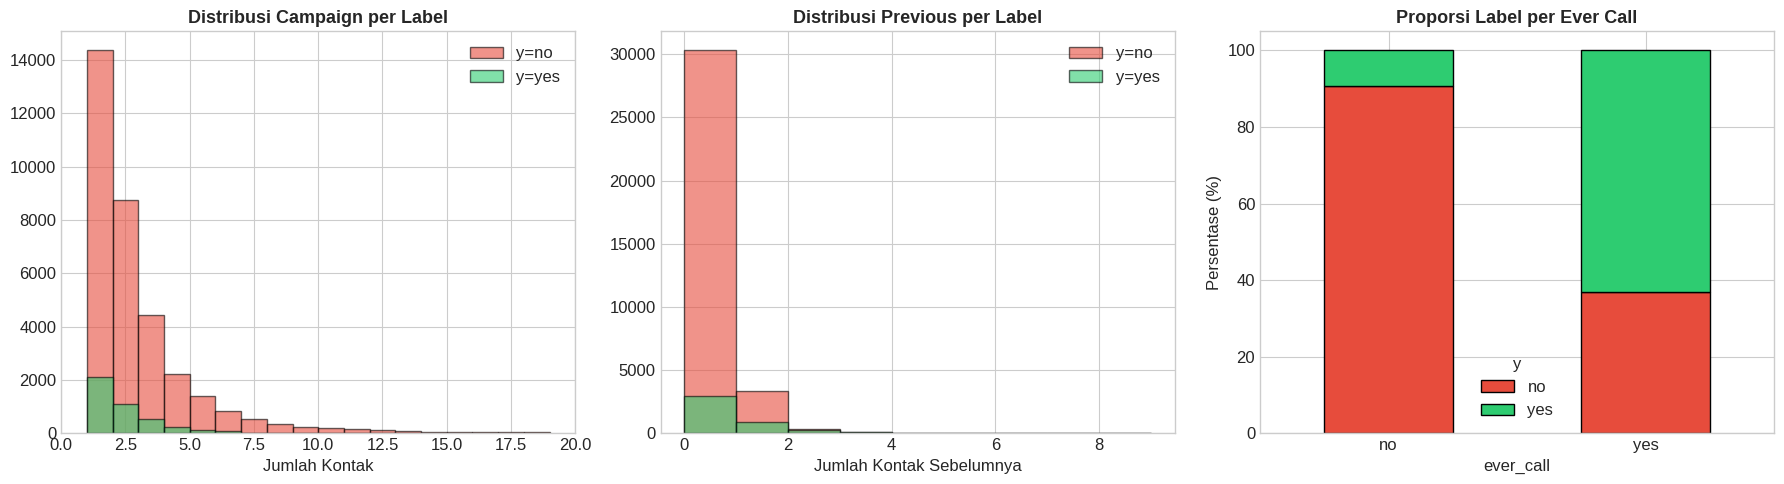

Insight:
- Jika dikontak > 2x pada promosi ini → lebih likely menolak
- Nasabah yang pernah dikontak sebelumnya → lebih likely deposito
- ~20% nasabah yang deposito pernah ditelpon sebelumnya


In [31]:
# Campaign, Previous, Ever Call
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Campaign
for label, color in zip(['no', 'yes'], ['#e74c3c', '#2ecc71']):
    subset = df[df['y'] == label]
    axes[0].hist(subset['campaign'], bins=range(1, 20), alpha=0.6, label=f'y={label}', color=color, edgecolor='black')
axes[0].set_title('Distribusi Campaign per Label', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jumlah Kontak')
axes[0].legend()
axes[0].set_xlim(0, 20)

# Previous
for label, color in zip(['no', 'yes'], ['#e74c3c', '#2ecc71']):
    subset = df[df['y'] == label]
    axes[1].hist(subset['previous'], bins=range(0, 10), alpha=0.6, label=f'y={label}', color=color, edgecolor='black')
axes[1].set_title('Distribusi Previous per Label', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Jumlah Kontak Sebelumnya')
axes[1].legend()

# Ever Call
ct_ever = pd.crosstab(df['ever_call'], df['y'])
pct_ever = ct_ever.div(ct_ever.sum(axis=1), axis=0) * 100
pct_ever.plot(kind='bar', stacked=True, ax=axes[2], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[2].set_title('Proporsi Label per Ever Call', fontsize=13, fontweight='bold')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)
axes[2].set_ylabel('Persentase (%)')

plt.tight_layout()
plt.show()

print("Insight:")
print("- Jika dikontak > 2x pada promosi ini → lebih likely menolak")
print("- Nasabah yang pernah dikontak sebelumnya → lebih likely deposito")
print("- ~20% nasabah yang deposito pernah ditelpon sebelumnya")

### 6.10 Distribusi Poutcome

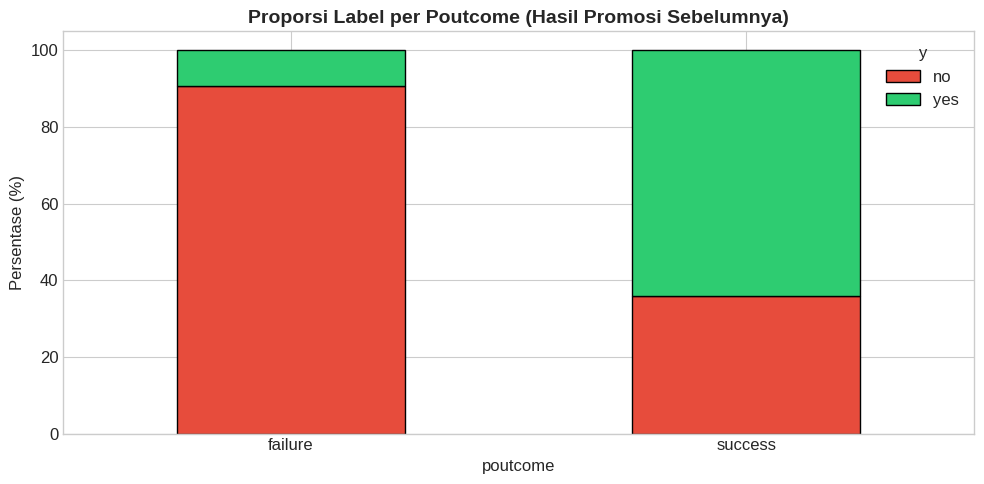

Insight: Nasabah yang sukses pada promosi sebelumnya lebih cenderung deposito lagi.


In [32]:
# Poutcome distribution
fig, ax = plt.subplots(figsize=(10, 5))

ct_pout = pd.crosstab(df['poutcome'], df['y'])
pct_pout = ct_pout.div(ct_pout.sum(axis=1), axis=0) * 100
pct_pout.plot(kind='bar', stacked=True, ax=ax, color=['#e74c3c', '#2ecc71'], edgecolor='black')
ax.set_title('Proporsi Label per Poutcome (Hasil Promosi Sebelumnya)', fontsize=14, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_ylabel('Persentase (%)')

plt.tight_layout()
plt.show()

print("Insight: Nasabah yang sukses pada promosi sebelumnya lebih cenderung deposito lagi.")

### 6.11 Distribusi Variabel Ekonomi

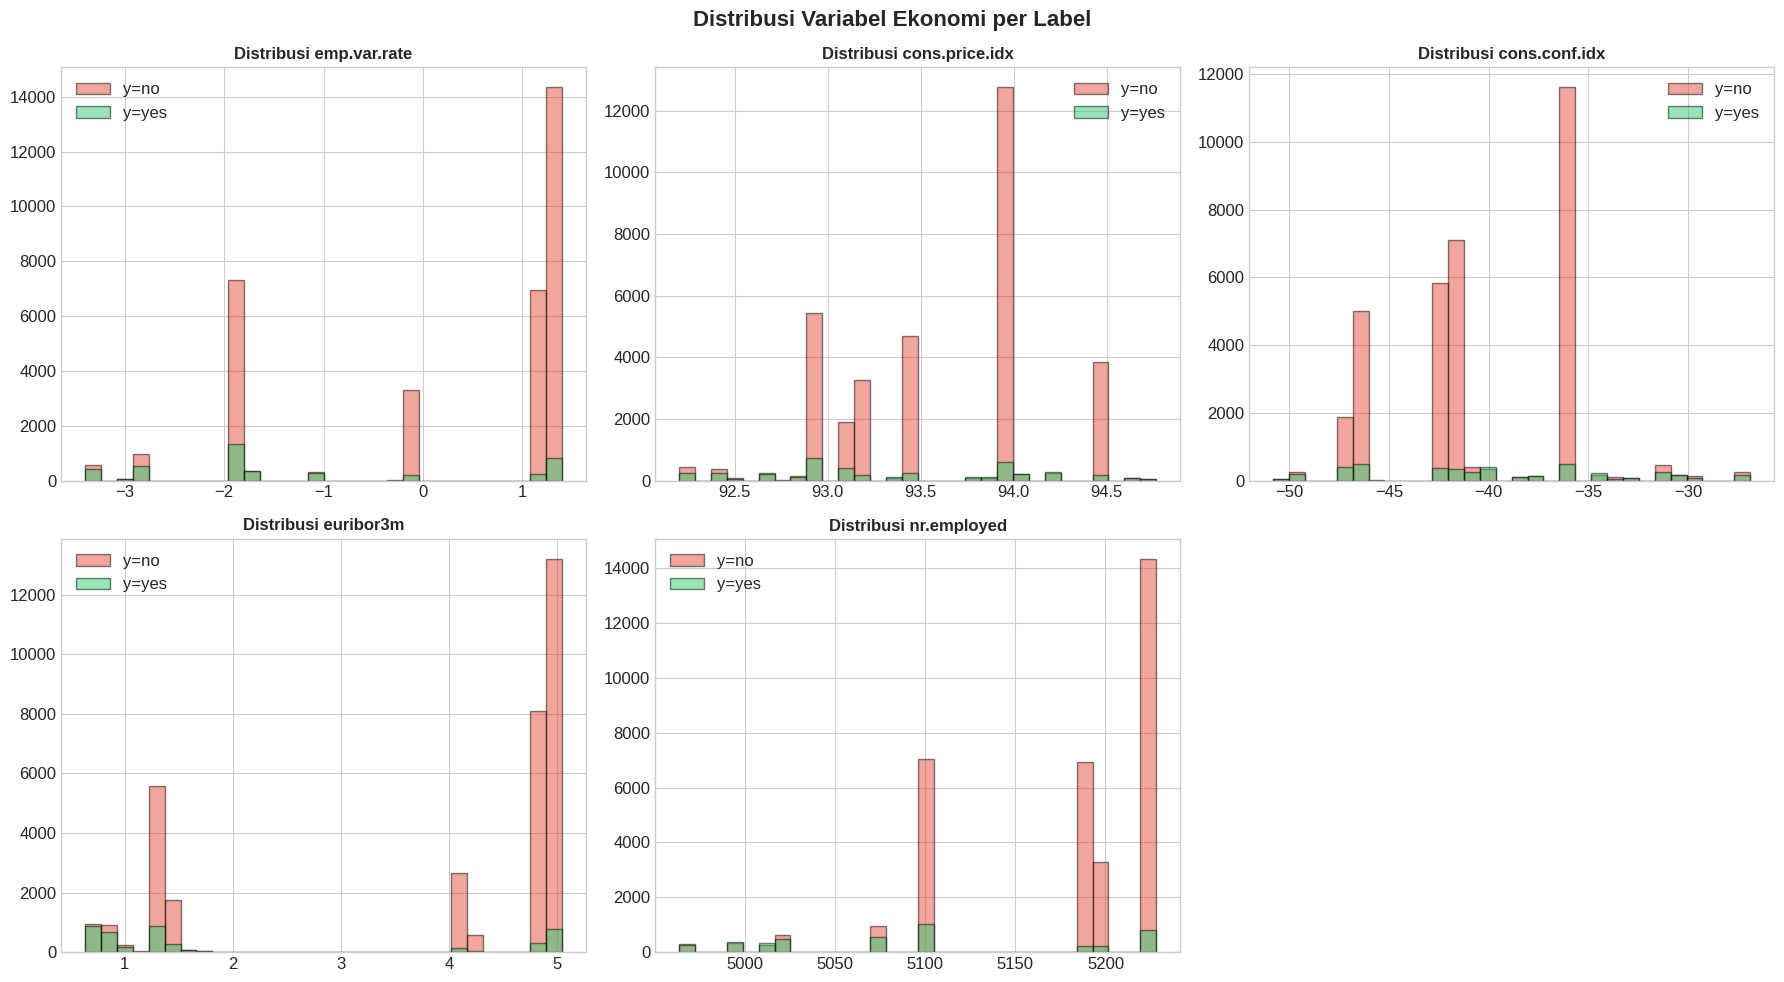

Insight:
- emp.var.rate ~1.5 → persentase 'yes' jauh lebih tinggi
- euribor3m < 2 → 'yes' lebih tinggi secara signifikan
- nr.employed < 5100 → 'yes' jauh lebih tinggi
- Variabel ekonomi menunjukkan pola yang kuat terhadap keputusan deposito


In [33]:
# Economic variables distribution
econ_vars = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, var in enumerate(econ_vars):
    for label, color in zip(['no', 'yes'], ['#e74c3c', '#2ecc71']):
        subset = df[df['y'] == label]
        axes[i].hist(subset[var], bins=30, alpha=0.5, label=f'y={label}', color=color, edgecolor='black')
    axes[i].set_title(f'Distribusi {var}', fontsize=12, fontweight='bold')
    axes[i].legend()

# Hide empty subplot
axes[5].set_visible(False)

plt.suptitle('Distribusi Variabel Ekonomi per Label', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("Insight:")
print("- emp.var.rate ~1.5 → persentase 'yes' jauh lebih tinggi")
print("- euribor3m < 2 → 'yes' lebih tinggi secara signifikan")
print("- nr.employed < 5100 → 'yes' jauh lebih tinggi")
print("- Variabel ekonomi menunjukkan pola yang kuat terhadap keputusan deposito")

### 6.12 Correlation Heatmap

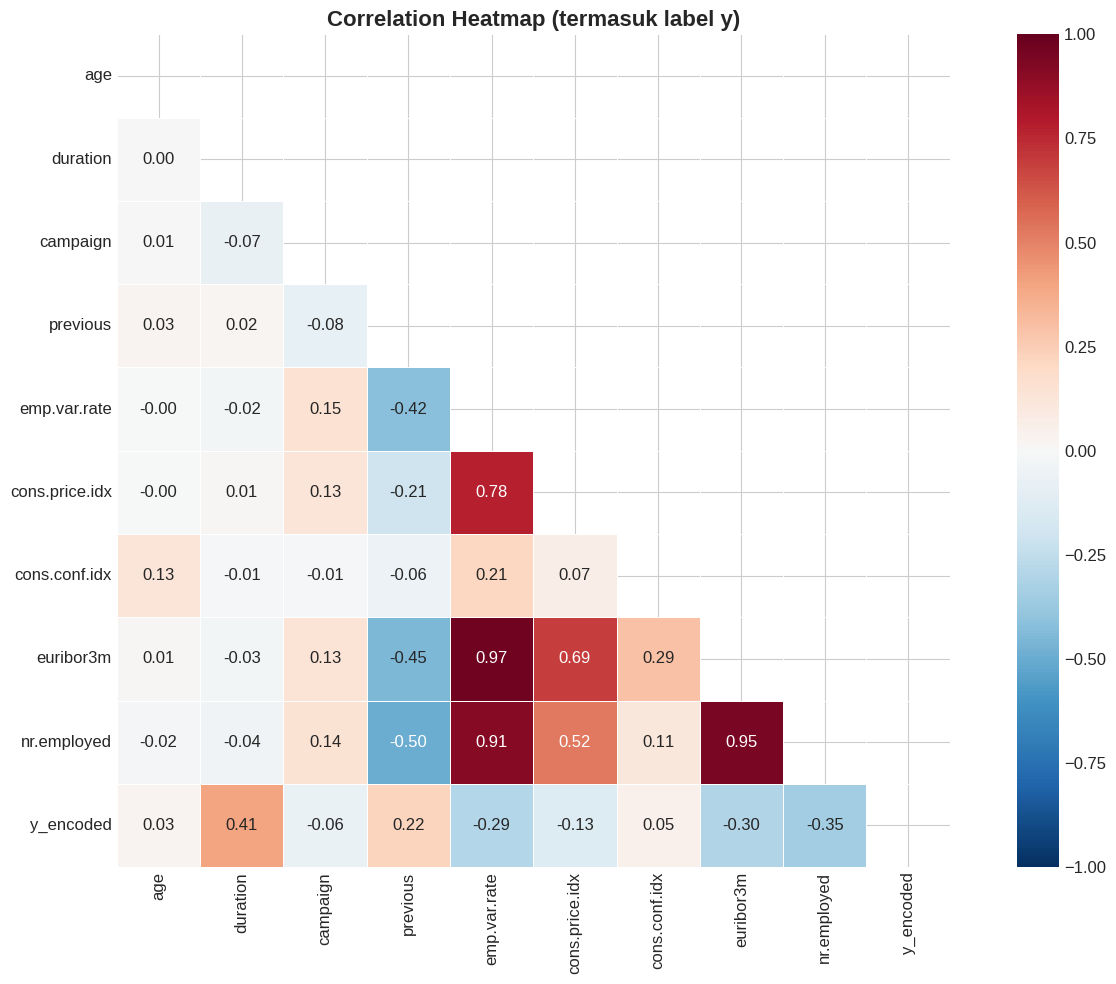


Korelasi dengan label 'y':
  nr.employed          : -0.347  -██████████
  euribor3m            : -0.300  -█████████
  emp.var.rate         : -0.292  -████████
  cons.price.idx       : -0.133  -███
  campaign             : -0.065  -█
  age                  : +0.029  +
  cons.conf.idx        : +0.051  +█
  previous             : +0.221  +██████
  duration             : +0.406  +████████████


In [34]:
# Correlation heatmap (numerik)
df_num = df.select_dtypes(include=['int64', 'float64'])

# Tambahkan label sebagai numerik
df_corr = df_num.copy()
df_corr['y_encoded'] = (df['y'] == 'yes').astype(int)

fig, ax = plt.subplots(figsize=(14, 10))
corr_matrix = df_corr.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5, square=True, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap (termasuk label y)', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nKorelasi dengan label 'y':")
corr_with_y = corr_matrix['y_encoded'].drop('y_encoded').sort_values()
for feat, val in corr_with_y.items():
    bar = '█' * int(abs(val) * 30)
    sign = '+' if val > 0 else '-'
    print(f"  {feat:20s} : {val:+.3f}  {sign}{bar}")

### 6.13 Correlation Score dengan Label

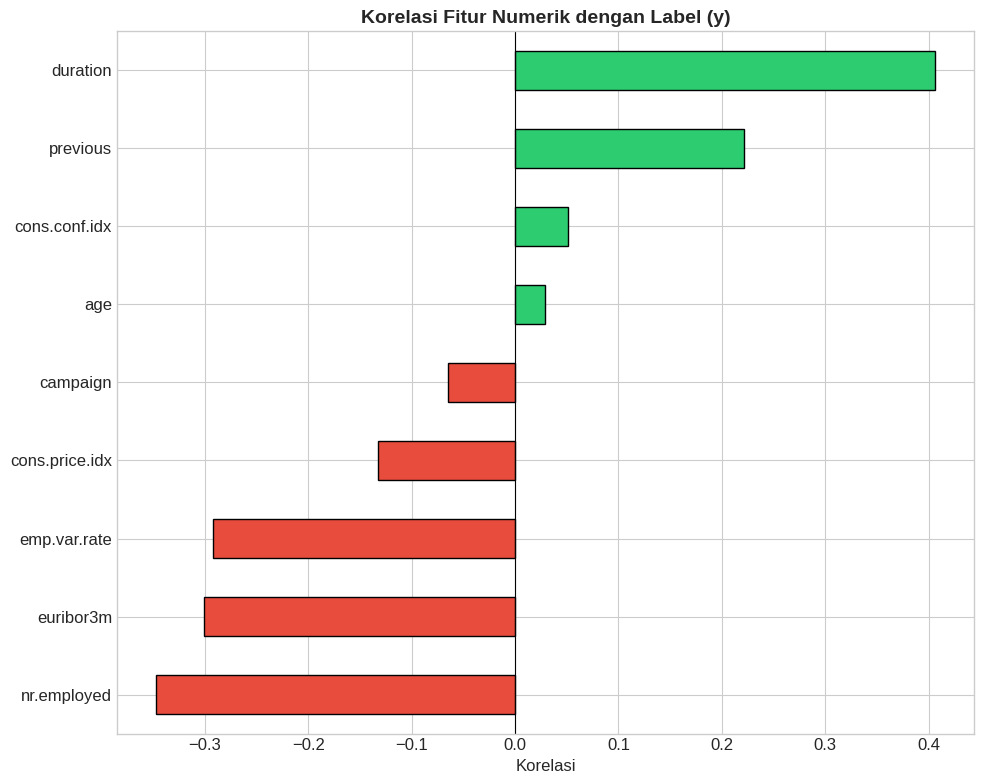

Temuan utama:
- Korelasi NEGATIF tertinggi : nr.employed (-0.347)
- Korelasi POSITIF tertinggi : duration (0.406)


In [35]:
# Correlation score sorted
fig, ax = plt.subplots(figsize=(10, 8))

corr_sorted = corr_with_y.sort_values()
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in corr_sorted.values]
corr_sorted.plot(kind='barh', color=colors, edgecolor='black', ax=ax)
ax.set_title('Korelasi Fitur Numerik dengan Label (y)', fontsize=14, fontweight='bold')
ax.set_xlabel('Korelasi')
ax.axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

print("Temuan utama:")
print(f"- Korelasi NEGATIF tertinggi : {corr_sorted.index[0]} ({corr_sorted.values[0]:.3f})")
print(f"- Korelasi POSITIF tertinggi : {corr_sorted.index[-1]} ({corr_sorted.values[-1]:.3f})")

### 6.14 Chi-Square Test (Fitur Kategorikal vs Label)

Chi-Square Test digunakan untuk mengukur hubungan antara variabel kategorikal dengan label `y`.  
Jika **p-value > 0.05**, maka fitur tersebut dianggap **tidak signifikan** berkorelasi dengan label.

In [36]:
# Chi-Square Test untuk fitur kategorikal
cat_cols = df.select_dtypes(include='object').columns.drop('y')

chi2_results = []
for col in cat_cols:
    contingency = pd.crosstab(df[col], df['y'])
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    chi2_results.append({
        'Fitur': col,
        'Chi2': round(chi2, 2),
        'P-Value': p_value,
        'Signifikan (p<0.05)': '✅ Ya' if p_value < 0.05 else '❌ Tidak'
    })

chi2_df = pd.DataFrame(chi2_results).sort_values('P-Value')
print("=" * 80)
print("HASIL CHI-SQUARE TEST")
print("=" * 80)
print()
print(chi2_df.to_string(index=False))

HASIL CHI-SQUARE TEST

      Fitur    Chi2       P-Value Signifikan (p<0.05)
      month 2860.96  0.000000e+00                ✅ Ya
   poutcome 3688.64  0.000000e+00                ✅ Ya
  ever_call 3877.78  0.000000e+00                ✅ Ya
    contact  764.46 2.885785e-168                ✅ Ya
        job  791.19 1.477069e-162                ✅ Ya
  education  174.74  4.436331e-35                ✅ Ya
    marital  101.25  1.033616e-22                ✅ Ya
day_of_week   22.89  1.330330e-04                ✅ Ya
    housing    4.03  4.469184e-02                ✅ Ya
       loan    1.32  2.501173e-01             ❌ Tidak


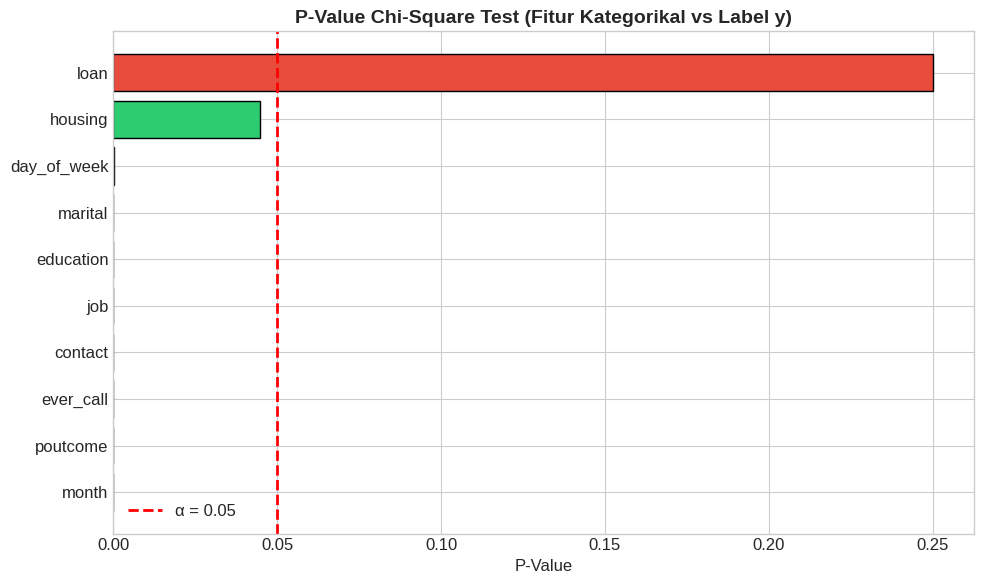


Fitur dengan P-Value > 0.05 (TIDAK signifikan):
  - loan (p-value = 0.2501)


In [37]:
# Visualisasi P-Value Chi-Square
fig, ax = plt.subplots(figsize=(10, 6))

chi2_sorted = chi2_df.sort_values('P-Value')
colors = ['#2ecc71' if p < 0.05 else '#e74c3c' for p in chi2_sorted['P-Value']]
ax.barh(chi2_sorted['Fitur'], chi2_sorted['P-Value'], color=colors, edgecolor='black')
ax.axvline(x=0.05, color='red', linestyle='--', linewidth=2, label='α = 0.05')
ax.set_title('P-Value Chi-Square Test (Fitur Kategorikal vs Label y)', fontsize=14, fontweight='bold')
ax.set_xlabel('P-Value')
ax.legend()

plt.tight_layout()
plt.show()

print("\nFitur dengan P-Value > 0.05 (TIDAK signifikan):")
not_sig = chi2_df[chi2_df['P-Value'] > 0.05]
if len(not_sig) > 0:
    for _, row in not_sig.iterrows():
        print(f"  - {row['Fitur']} (p-value = {row['P-Value']:.4f})")
else:
    print("  Semua fitur kategorikal signifikan.")

## 7. Kesimpulan EDA

Dari hasil exploratory data analysis, beberapa kesimpulan yang dapat diambil:

1. **Imbalanced Dataset** — Data yang dimiliki sangat timpang, hanya ~11% nasabah berlabel 'yes'.

2. **Fitur Tidak Signifikan** — Data seperti `marital`, `housing`, `loan`, dan `month` terlihat tidak signifikan mempengaruhi label berdasarkan korelasi dan chi-square test.

3. **Fitur Signifikan** — Terdapat pattern yang kuat pada kolom `ever_call`, `poutcome`, `emp.var.rate`, `cons.conf.idx`, `euribor3m`, dan `nr.employed`.

4. **Korelasi Variabel Ekonomi** — Fitur-fitur ekonomi memiliki korelasi tinggi satu sama lain (multikolinearitas).

5. **Duration** — Meskipun `duration` memiliki korelasi tertinggi dengan label, fitur ini tidak relevan untuk prediksi karena hanya diketahui setelah panggilan selesai.

---
*Modul 2: Python for Data Analysis — Bank Telemarketing Project*  
*Machine Learning — UNIBI*